In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import joblib
import os
import warnings
warnings.filterwarnings('ignore') #ignore warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from prophet import Prophet

plt.style.use('seaborn-v0_8-darkgrid')
os.makedirs('data/processed',exist_ok=True)
os.makedirs('models', exist_ok=True)

print('Libraries loaded...!')

Libraries loaded...!


In [5]:
# ── Load CSVs ──────────────────────────────────────────────────
txn    = pd.read_csv('raw/walmart_transactions.csv')
stores = pd.read_csv('raw/store_locations.csv')
prod   = pd.read_csv('raw/product_catalog.csv')
dc     = pd.read_csv('raw/distribution_centers.csv')

# ── Load SQLite DB ─────────────────────────────────────────────────
conn        = sqlite3.connect('raw/inventory_and_sales.db')
daily_sales = pd.read_sql('SELECT * FROM daily_sales_summary', conn)
inventory   = pd.read_sql('SELECT * FROM inventory_levels',    conn)
conn.close()

print(f'Transactions : {txn.shape}')
print(f'Stores       : {stores.shape}')
print(f'Products     : {prod.shape}')
print(f'DCs          : {dc.shape}')
print(f'Daily sales  : {daily_sales.shape}')
print(f'Inventory    : {inventory.shape}')

Transactions : (25562, 8)
Stores       : (14, 8)
Products     : (45, 7)
DCs          : (5, 8)
Daily sales  : (3600, 5)
Inventory    : (4320, 6)


# Data Cleaning
## Transactions


In [6]:
print('=== RAW ISSUES ===')
print('Unique store_id formates: ', sorted(txn['store_id'].unique())[:15])
print('\nCategory variants: ', sorted(txn['category'].unique()))
print('\nMissing values: \n', txn.isnull().sum())

=== RAW ISSUES ===
Unique store_id formates:  [' FL-078', ' FL-105', ' FL-156', ' FL-239', ' FL-287', ' FL-302', ' FL-330', ' FL-412', ' FL-445', ' FL-501', ' FL-619', ' FL-710', 'FL-078', 'FL-105', 'FL-156']

Category variants:  ['ALCOHOL', 'Alcohol', 'Alcoholic Beverages', 'BABY', 'BREAKFAST', 'Baby', 'Baby Products', 'Breakfast', 'Breakfast Foods', 'ELECTRONICS', 'EMERGENCY', 'ENTERTAINMENT', 'Electronics', 'Emergency', 'Emergency Supplies', 'Entertainment', 'GROCERY', 'Games & Entertainment', 'Groceries', 'Grocery', 'HEALTH', 'HOUSEHOLD', 'Health', 'Health & Wellness', 'Household', 'Household Essentials', 'SNACKS', 'Snacks', 'baby', 'breakfast', 'electronics', 'emergency', 'entertainment', 'grocery', 'health', 'household', 'snacks']

Missing values: 
 transaction_id      0
store_id            0
timestamp         886
sku                 0
product_name        0
category            0
quantity            0
unit_price          0
dtype: int64


In [7]:
# ── Fix store_id: uppercase, replace underscores, strip spaces ─────────────
txn['store_id'] = (
    txn['store_id']
    .str.strip()
    .str.upper()
    .str.replace('_', '-', regex=False)
)

# ── Fix category: lowercase, then map to canonical names ──────────────────
category_map = {
    'grocery': 'Grocery',
    'groceries': 'Grocery',
    'breakfast': 'Breakfast',
    'breakfast foods': 'Breakfast',
    'emergency': 'Emergency',
    'emergency supplies': 'Emergency',
    'electronics': 'Electronics',
    'entertainment': 'Entertainment',
    'games & entertainment': 'Entertainment',
    'alcohol': 'Alcohol',
    'alcoholic beverages': 'Alcohol',
    'snacks': 'Snacks',
    'household': 'Household',
    'household essentials': 'Household',
    'health': 'Health',
    'health & wellness': 'Health',
    'baby': 'Baby',
    'baby products': 'Baby',
}
txn['category'] = txn['category'].str.strip().str.lower().map(category_map)


# ── Fix unit_price: remove $, convert to float ─────────────────────────────
txn['unit_price'] = (
    txn['unit_price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.strip()
    .astype(float)
)

# ── Parse timestamps ───────────────────────────────────────────────────────
txn['timestamp'] = pd.to_datetime(txn['timestamp'], format='mixed')
txn['date']      = txn['timestamp'].dt.date
txn['date']      = pd.to_datetime(txn['date'])
txn['hour']      = txn['timestamp'].dt.hour
txn['dayofweek'] = txn['timestamp'].dt.dayofweek   # 0=Mon
txn['day']       = txn['timestamp'].dt.day
txn['week'] = txn['timestamp'].dt.isocalendar().week.astype('Int64').fillna(0).astype(int)

# ── Add revenue column ─────────────────────────────────────────────────────
txn['revenue'] = txn['quantity'] * txn['unit_price']

# ── Drop unmappable categories ─────────────────────────────────────────────
before = len(txn)

txn.dropna(subset=['category'], inplace=True)
print(f'Rows dropped (unmapped category): {before - len(txn)}')
print(f'\n Transactions cleaned: {txn.shape}')
print(txn[['store_id','category','unit_price','revenue']].head())


Rows dropped (unmapped category): 0

 Transactions cleaned: (25562, 14)
  store_id     category  unit_price  revenue
0   FL-710      Grocery        3.15     3.15
1   FL-412      Grocery        2.02     2.02
2   FL-105    Household       10.47    20.94
3   FL-330  Electronics       28.59    28.59
4   FL-302      Alcohol       18.82    56.46


In [8]:
# Store Locations
# ── Fix store_id: same normalization as transactions ───────────────────────
stores['store_id'] = (
    stores['store_id']
    .str.strip()
    .str.upper()
    .str.replace('_', '-', regex=False)
)

# ── Fix region: strip whitespace ──────────────────────────────────────────
stores['region'] = stores['region'].str.strip()

print('✅ Stores cleaned')
print(stores[['store_id','city','region']].to_string(index=False))


✅ Stores cleaned
store_id           city    region
  FL-239        Orlando   Central
  FL-105          Tampa      West
  FL-330          Miami     South
  FL-412   Jacksonville     North
  FL-287      Kissimmee   Central
  FL-156  Daytona Beach      East
  FL-501     Fort Myers      West
  FL-078    Gainesville     North
  FL-619    Tallahassee Panhandle
  FL-445 St. Petersburg      West
  FL-302       Lakeland   Central
  FL-710      Pensacola Panhandle
   FL239        Orlando   Central
  FL-287      Kissimmee   Central


In [9]:
# product Catalog

# ── Normalize category in catalog ─────────────────────────────────────────
prod['category'] = prod['category'].str.strip().str.lower().map(category_map)

# ── Fill missing unit_cost with category median ───────────────────────────
prod['unit_cost'] = prod.groupby('category')['unit_cost'].transform(
    lambda x: x.fillna(x.median())
)
# fallback: overall median
prod['unit_cost'].fillna(prod['unit_cost'].median(), inplace=True)

print(f'Product catalog cleaned: {prod.shape}')
print(f'Missing unit_cost after fix: {prod["unit_cost"].isna().sum()}')
print(prod[['sku','product_name','category','unit_cost']].head(8))

Product catalog cleaned: (45, 7)
Missing unit_cost after fix: 0
             sku           product_name   category  unit_cost
0          PT-12   pop-tarts strawberry  Breakfast       1.93
1     SKU#459812    Strawberry Pop-Tart  Breakfast       2.26
2  POPTART-STRAW   Pop-Tarts Strawberry  Breakfast       2.11
3  PT_STRAWBERRY   pop-tarts strawberry  Breakfast       2.11
4         WTR-24     BOTTLED WATER 24PK  Emergency       2.64
5      WATER24PK  Bottled Water 24-Pack  Emergency       2.38
6       WTR_24PK        Water - 24 Pack  Emergency       2.08
7       BATT-100       BATTERIES AA 4PK  Emergency       3.71


In [10]:
# Distribution Centers

# ── Clean surge_capacity: remove ~, convert to int ─────────────────────────
dc['surge_capacity'] = (
    dc['surge_capacity']
    .astype(str)
    .str.replace('~', '', regex=False)
    .str.strip()
    .astype(int)
)

# ── Fill missing cost_per_shipment with median ─────────────────────────────
dc['cost_per_shipment'].fillna(dc['cost_per_shipment'].median(), inplace=True)

print(' Distribution centers cleaned')
print(dc.to_string(index=False))

 Distribution centers cleaned
 dc_id                          dc_name         city state  avg_daily_shipments  surge_capacity  distance_to_orlando_mi  cost_per_shipment
DC-JAX Jacksonville Distribution Center Jacksonville    FL                  500            1000                     141             245.00
DC-ATL      Atlanta Distribution Center      Atlanta    GA                  400             700                     438             412.50
DC-DAL       Dallas Distribution Center       Dallas    TX                  300             600                    1108             687.00
DC-MIA        Miami Distribution Center        Miami    FL                  350             750                     235             298.00
DC-BHM   Birmingham Distribution Center   Birmingham    AL                  250             500                     503             355.25


In [11]:
# Merge All Dataset
# ── Merge transactions + store locations ──────────────────────────────────
df = txn.merge(stores, on='store_id', how='left', suffixes=('', '_store'))
print(f'After store merge : {df.shape} | Unmatched stores: {df["city"].isna().sum()}')

# ── Merge + product catalog ────────────────────────────────────────────────
df = df.merge(prod[['sku','unit_cost','supplier','subcategory']], on='sku', how='left')
print(f'After product merge: {df.shape} | Missing unit_cost: {df["unit_cost"].isna().sum()}')

# ── Add margin column ──────────────────────────────────────────────────────
df['margin']        = df['unit_price'] - df['unit_cost']
df['margin_pct']    = (df['margin'] / df['unit_price'] * 100).round(2)

print(f'\n✅ Final merged shape: {df.shape}')
print(df[['transaction_id','store_id','city','region','category','revenue','margin_pct']].head())

After store merge : (27601, 21) | Unmatched stores: 908
After product merge: (27601, 24) | Missing unit_cost: 0

✅ Final merged shape: (27601, 26)
  transaction_id store_id          city     region     category  revenue  \
0      TXN012636   FL-710     Pensacola  Panhandle      Grocery     3.15   
1      TXN000759   FL-412  Jacksonville      North      Grocery     2.02   
2      TXN003338   FL-105         Tampa       West    Household    20.94   
3      TXN025020   FL-330         Miami      South  Electronics    28.59   
4      TXN015797   FL-302      Lakeland    Central      Alcohol    56.46   

   margin_pct  
0       38.41  
1       41.09  
2       45.08  
3       40.57  
4       48.88  


In [12]:
# ── Save cleaned master dataset ────────────────────────────────────────────
df.to_csv('data/processed/walmart_master.csv', index=False)
print('✅ Saved: data/processed/walmart_master.csv')

✅ Saved: data/processed/walmart_master.csv


In [13]:
print('==='*40)
print(' '*25, 'Exploratory Data Analysis (EDA)')
print('==='*40)
print('=== OVERVIEW ===')
print(f'Date range  : {df["date"].min()} → {df["date"].max()}')
print(f'Stores      : {df["store_id"].nunique()}')
print(f'Categories  : {df["category"].nunique()}')
print(f'Total revenue: ${df["revenue"].sum():,.2f}')
print(f'Avg transaction: ${df["revenue"].mean():.2f}')
print(f'\nRevenue by category:')
print(df.groupby('category')['revenue'].sum().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}'))


                          Exploratory Data Analysis (EDA)
=== OVERVIEW ===
Date range  : 2024-09-01 00:00:00 → 2024-09-30 00:00:00
Stores      : 24
Categories  : 10
Total revenue: $574,166.12
Avg transaction: $20.80

Revenue by category:
category
Emergency        $162,158
Electronics       $92,257
Baby              $91,154
Entertainment     $55,982
Alcohol           $53,125
Household         $34,438
Health            $29,274
Breakfast         $19,389
Snacks            $18,855
Grocery           $17,533
Name: revenue, dtype: object


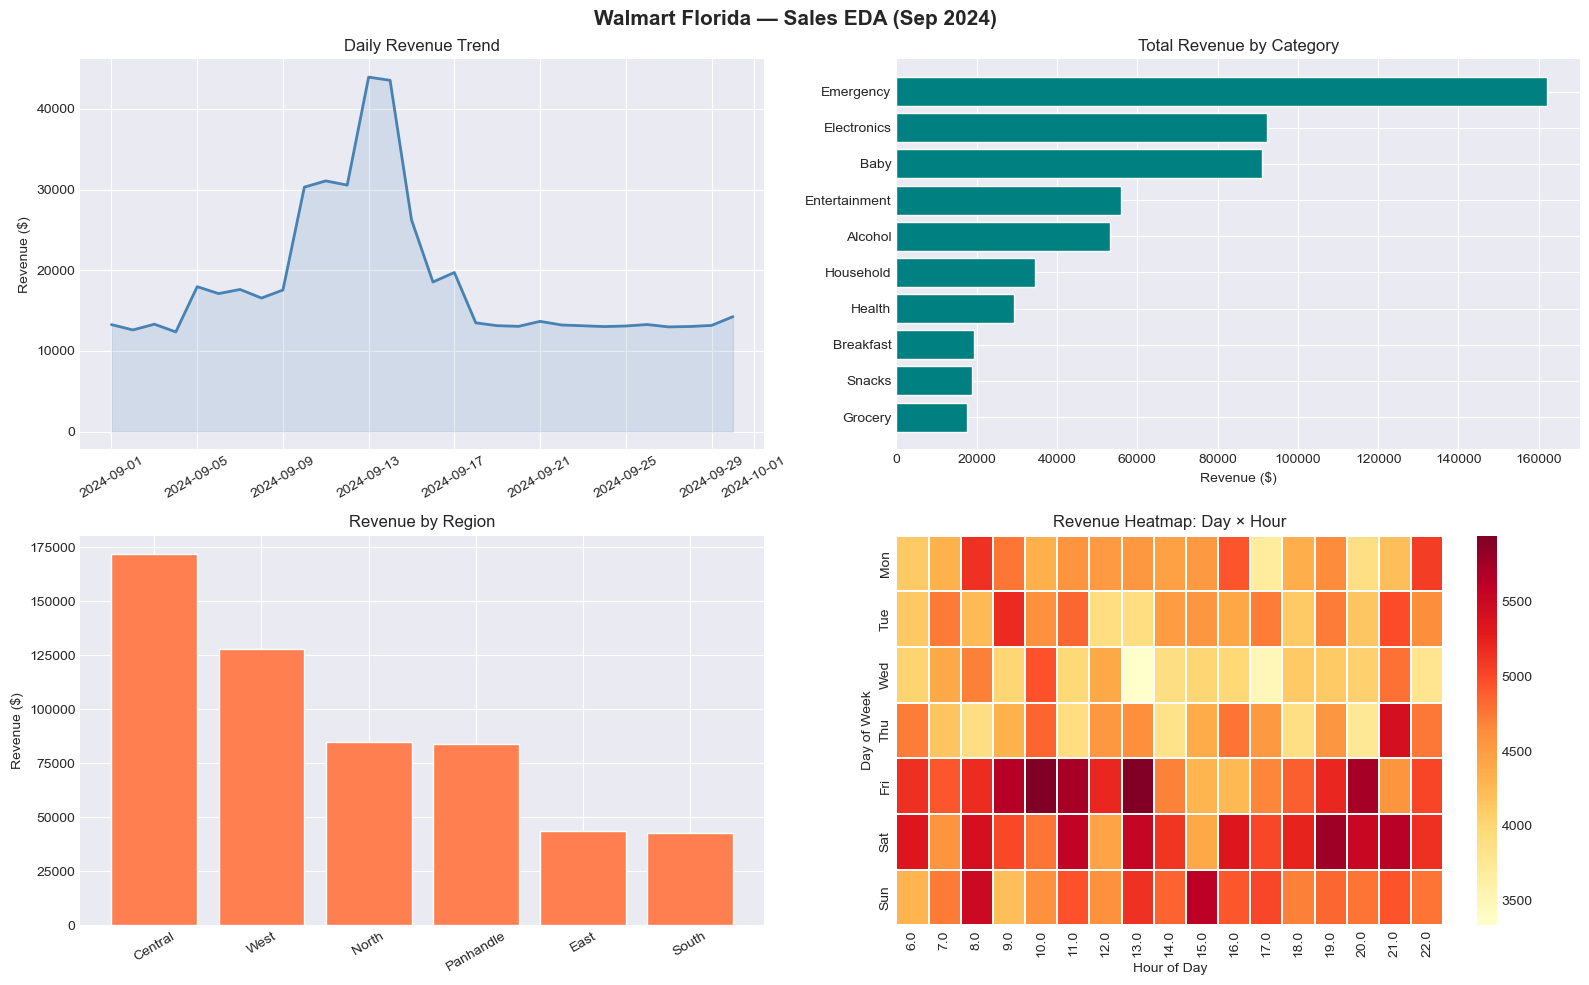

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Walmart Florida — Sales EDA (Sep 2024)', fontsize=15, fontweight='bold')

# 1. Daily revenue trend
daily = df.groupby('date')['revenue'].sum().reset_index()
axes[0,0].plot(daily['date'], daily['revenue'], color='steelblue', linewidth=2)
axes[0,0].fill_between(daily['date'], daily['revenue'], alpha=0.15, color='steelblue')
axes[0,0].set_title('Daily Revenue Trend')
axes[0,0].set_ylabel('Revenue ($)')
axes[0,0].tick_params(axis='x', rotation=30)

# 2. Revenue by category
cat_rev = df.groupby('category')['revenue'].sum().sort_values()
axes[0,1].barh(cat_rev.index, cat_rev.values, color='teal', edgecolor='white')
axes[0,1].set_title('Total Revenue by Category')
axes[0,1].set_xlabel('Revenue ($)')

# 3. Revenue by region
reg_rev = df.groupby('region')['revenue'].sum().sort_values(ascending=False)
axes[1,0].bar(reg_rev.index, reg_rev.values, color='coral', edgecolor='white')
axes[1,0].set_title('Revenue by Region')
axes[1,0].set_ylabel('Revenue ($)')
axes[1,0].tick_params(axis='x', rotation=30)

# 4. Hourly sales heatmap
heatmap_data = df.groupby(['dayofweek','hour'])['revenue'].sum().unstack(fill_value=0)
heatmap_data.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
sns.heatmap(heatmap_data, ax=axes[1,1], cmap='YlOrRd', fmt='.0f', linewidths=0.3)
axes[1,1].set_title('Revenue Heatmap: Day × Hour')
axes[1,1].set_xlabel('Hour of Day')
axes[1,1].set_ylabel('Day of Week')

plt.tight_layout()
plt.show()

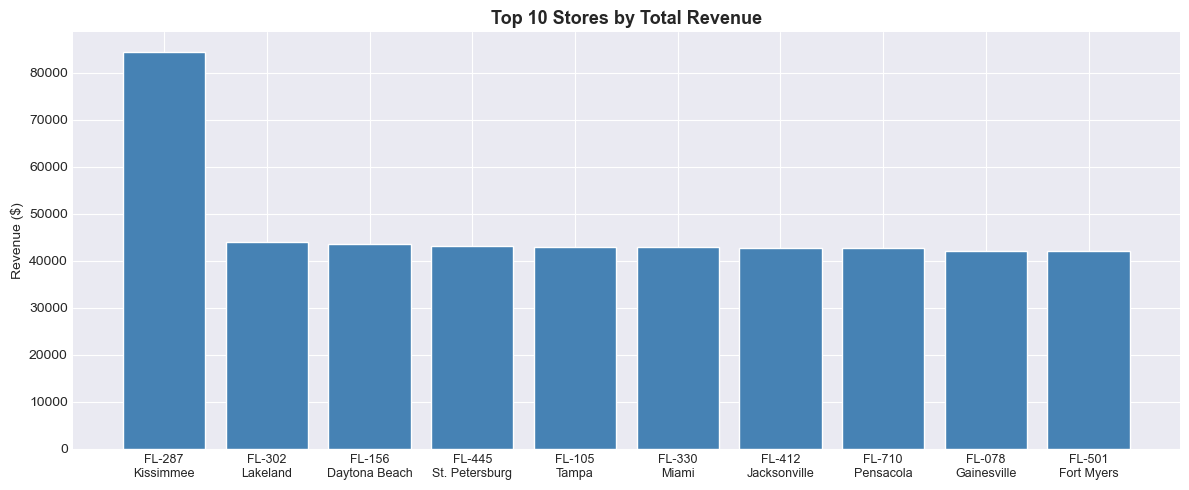

In [15]:
# Top 10 stores by revenue
top_stores = df.groupby(['store_id','city'])['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
labels = [f"{sid}\n{city}" for (sid, city) in top_stores.index]
plt.bar(range(len(top_stores)), top_stores.values, color='steelblue', edgecolor='white')
plt.xticks(range(len(top_stores)), labels, fontsize=9)
plt.title('Top 10 Stores by Total Revenue', fontsize=13, fontweight='bold')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

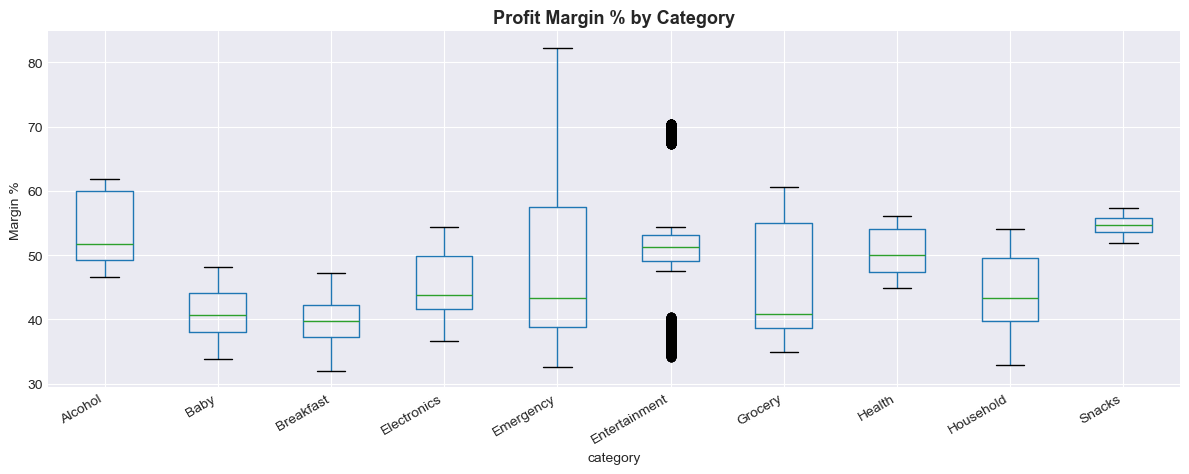

In [16]:
# Margin analysis by category
margin_df = df.dropna(subset=['margin_pct'])

plt.figure(figsize=(12, 5))
margin_df.boxplot(column='margin_pct', by='category', figsize=(12,5))
plt.suptitle('')
plt.title('Profit Margin % by Category', fontsize=13, fontweight='bold')
plt.ylabel('Margin %')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [17]:
print('==='*40)
print(' '*25, 'Feature Engineering')
print('==='*40)
# ── Aggregate to daily level for forecasting ───────────────────────────────
# (transaction-level is too granular for time series models)
daily_agg = df.groupby(['date', 'store_id', 'category']).agg(
    total_units   = ('quantity', 'sum'),
    total_revenue = ('revenue', 'sum'),
    num_transactions = ('transaction_id', 'count'),
    avg_price     = ('unit_price', 'mean'),
    avg_margin    = ('margin_pct', 'mean')
).reset_index()

# ── Add time features ──────────────────────────────────────────────────────
daily_agg['dayofweek']   = daily_agg['date'].dt.dayofweek
daily_agg['day']         = daily_agg['date'].dt.day
daily_agg['week']        = daily_agg['date'].dt.isocalendar().week.astype(int)
daily_agg['is_weekend']  = (daily_agg['dayofweek'] >= 5).astype(int)
daily_agg['month_start'] = (daily_agg['day'] <= 3).astype(int)   # paycheck effect
daily_agg['month_end']   = (daily_agg['day'] >= 27).astype(int)

# ── Encode categoricals ────────────────────────────────────────────────────
le_cat   = LabelEncoder()
le_store = LabelEncoder()
daily_agg['category_enc'] = le_cat.fit_transform(daily_agg['category'])
daily_agg['store_enc']    = le_store.fit_transform(daily_agg['store_id'])

# ── Lag features: revenue from 1, 7 days ago ──────────────────────────────
daily_agg = daily_agg.sort_values(['store_id','category','date'])
daily_agg['lag_1d']  = daily_agg.groupby(['store_id','category'])['total_revenue'].shift(1)
daily_agg['lag_7d']  = daily_agg.groupby(['store_id','category'])['total_revenue'].shift(7)
daily_agg['roll_3d'] = (
    daily_agg.groupby(['store_id','category'])['total_revenue']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# ── Fill lag NaNs with 0 (start of series) ────────────────────────────────
daily_agg[['lag_1d','lag_7d','roll_3d']] = daily_agg[['lag_1d','lag_7d','roll_3d']].fillna(0)

print(f'✅ Daily aggregated features: {daily_agg.shape}')
print(daily_agg.head())

                          Feature Engineering
✅ Daily aggregated features: (4363, 19)
          date store_id category  total_units  total_revenue  \
0   2024-09-01   FL-078  Alcohol            6         113.03   
140 2024-09-02   FL-078  Alcohol           11         208.89   
277 2024-09-03   FL-078  Alcohol            9         170.83   
411 2024-09-04   FL-078  Alcohol            6         113.94   
553 2024-09-05   FL-078  Alcohol           11         210.19   

     num_transactions  avg_price  avg_margin  dayofweek  day  week  \
0                   3  18.813333   52.213333          6    1    35   
140                 4  19.065000   54.852500          0    2    36   
277                 4  19.075000   52.185000          1    3    36   
411                 3  18.873333   56.066667          2    4    36   
553                 4  19.060000   54.682500          3    5    36   

     is_weekend  month_start  month_end  category_enc  store_enc  lag_1d  \
0             1            1    

In [18]:
# ── Save processed data ────────────────────────────────────────────────────
daily_agg.to_csv('data/processed/daily_aggregated.csv', index=False)
print('✅ Saved: data/processed/daily_aggregated.csv')

✅ Saved: data/processed/daily_aggregated.csv


In [19]:
print('==='*40)
print(' '*25, 'Model 1: Prophet (Store-Level Forecast)')
print('==='*40)
# ── Aggregate total daily revenue across all stores ───────────────────────
# (Prophet works best on a single time series; use total or per-store)
store_daily = (
    daily_agg
    .groupby('date')['total_revenue']
    .sum()
    .reset_index()
    .rename(columns={'date': 'ds', 'total_revenue': 'y'})
    .sort_values('ds')
)

print(f'Prophet input: {store_daily.shape}')
print(store_daily)

                          Model 1: Prophet (Store-Level Forecast)
Prophet input: (30, 2)
           ds         y
0  2024-09-01  13263.95
1  2024-09-02  12600.56
2  2024-09-03  13314.06
3  2024-09-04  12358.18
4  2024-09-05  17966.22
5  2024-09-06  17107.00
6  2024-09-07  17622.14
7  2024-09-08  16556.42
8  2024-09-09  17553.67
9  2024-09-10  30302.88
10 2024-09-11  31080.80
11 2024-09-12  30556.33
12 2024-09-13  43939.41
13 2024-09-14  43546.42
14 2024-09-15  26258.31
15 2024-09-16  18544.01
16 2024-09-17  19721.85
17 2024-09-18  13480.92
18 2024-09-19  13130.68
19 2024-09-20  13049.53
20 2024-09-21  13666.20
21 2024-09-22  13217.32
22 2024-09-23  13119.27
23 2024-09-24  13019.66
24 2024-09-25  13092.65
25 2024-09-26  13271.68
26 2024-09-27  12979.62
27 2024-09-28  13028.61
28 2024-09-29  13161.79
29 2024-09-30  14246.11


Train: 23 days | Test: 7 days


17:03:07 - cmdstanpy - INFO - Chain [1] start processing
17:03:12 - cmdstanpy - INFO - Chain [1] done processing


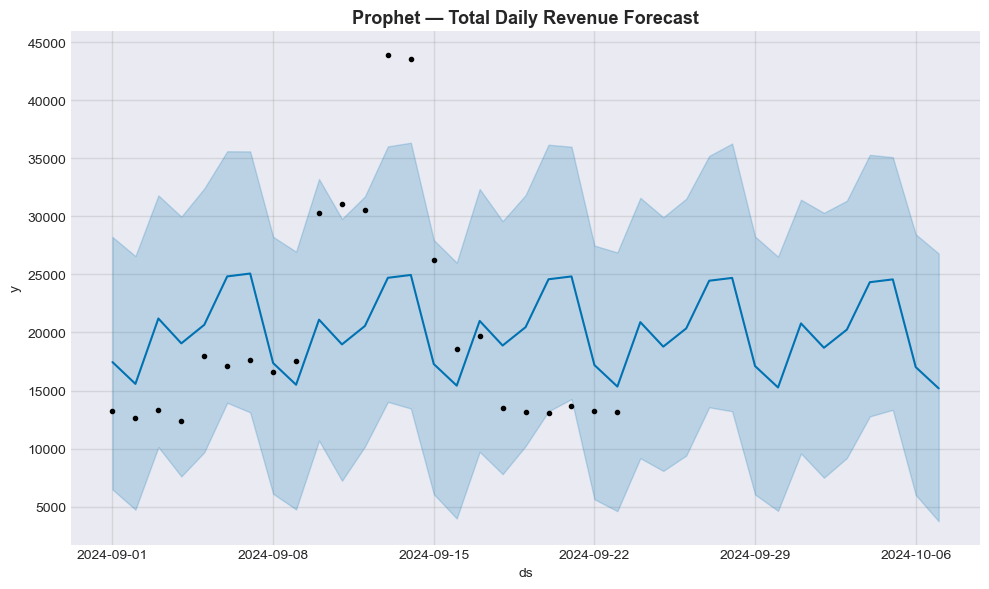

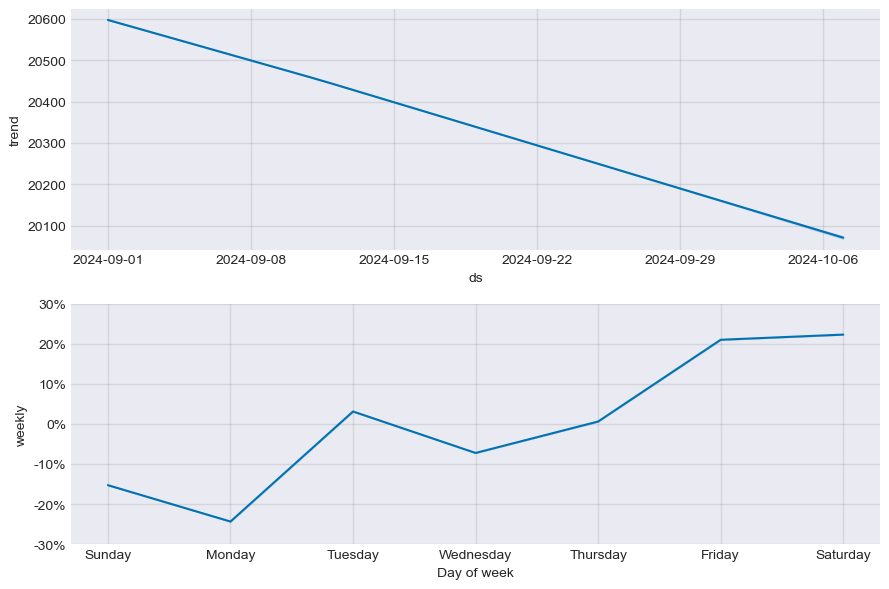

In [20]:
# ── Train / test split (last 7 days as test) ──────────────────────────────
split_date = store_daily['ds'].max() - pd.Timedelta(days=7)
train_p    = store_daily[store_daily['ds'] <= split_date]
test_p     = store_daily[store_daily['ds'] >  split_date]

print(f'Train: {len(train_p)} days | Test: {len(test_p)} days')

# ── Fit Prophet ────────────────────────────────────────────────────────────
model_p = Prophet(
    yearly_seasonality  = False,
    weekly_seasonality  = True,
    daily_seasonality   = False,
    changepoint_prior_scale = 0.1,
    seasonality_mode    = 'multiplicative'
)
model_p.fit(train_p)

# ── Forecast ───────────────────────────────────────────────────────────────
future   = model_p.make_future_dataframe(periods=14, freq='D')
forecast = model_p.predict(future)

# ── Plot ───────────────────────────────────────────────────────────────────
fig = model_p.plot(forecast)
plt.title('Prophet — Total Daily Revenue Forecast', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

fig2 = model_p.plot_components(forecast)
plt.tight_layout()
plt.show()

In [21]:
# ── Evaluate on test set ───────────────────────────────────────────────────
pred_p  = forecast[forecast['ds'].isin(test_p['ds'])]['yhat'].values
actual  = test_p['y'].values

mae_p   = mean_absolute_error(actual, pred_p)
rmse_p  = np.sqrt(mean_squared_error(actual, pred_p))
mape_p  = np.mean(np.abs((actual - pred_p) / (actual + 1e-5))) * 100

print('📊 Prophet Results:')
print(f'   MAE  : ${mae_p:,.2f}')
print(f'   RMSE : ${rmse_p:,.2f}')
print(f'   MAPE : {mape_p:.2f}%')

📊 Prophet Results:
   MAE  : $6,964.31
   RMSE : $7,829.19
   MAPE : 53.20%


                          Model 2: XGBoost (Category × Store Forecast)
Train: (3379, 13) | Test: (984, 13)
[0]	validation_0-rmse:97.63323
[100]	validation_0-rmse:25.13624
[200]	validation_0-rmse:24.35560
[300]	validation_0-rmse:24.39592
[399]	validation_0-rmse:24.59963

✅ XGBoost trained!
📊 XGBoost Results:
   MAE  : $16.12
   RMSE : $24.60
   MAPE : 39.04%


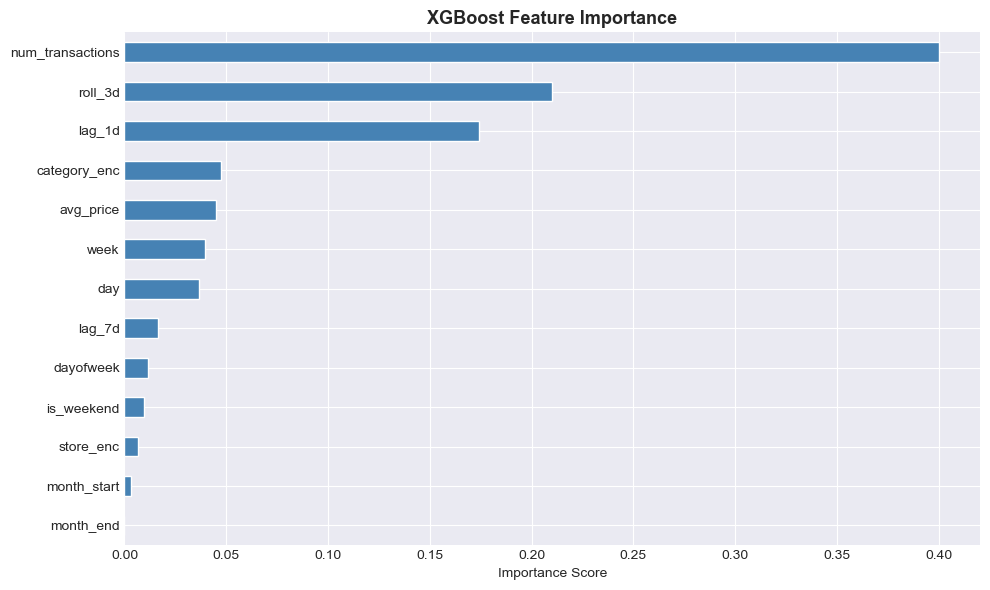

In [22]:
print('==='*40)
print(' '*25, 'Model 2: XGBoost (Category × Store Forecast)')
print('==='*40)

FEATURES = [
    'store_enc', 'category_enc',
    'dayofweek', 'day', 'week',
    'is_weekend', 'month_start', 'month_end',
    'num_transactions', 'avg_price',
    'lag_1d', 'lag_7d', 'roll_3d'
]
TARGET = 'total_revenue'

# ── Drop rows with NaN in features ────────────────────────────────────────
model_df = daily_agg.dropna(subset=FEATURES + [TARGET]).copy()

# ── Train / test split by date ────────────────────────────────────────────
split = model_df['date'].max() - pd.Timedelta(days=7)
X_train = model_df[model_df['date'] <= split][FEATURES]
y_train = model_df[model_df['date'] <= split][TARGET]
X_test  = model_df[model_df['date'] >  split][FEATURES]
y_test  = model_df[model_df['date'] >  split][TARGET]

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

# ── Train XGBoost ──────────────────────────────────────────────────────────
xgb = XGBRegressor(
    n_estimators       = 400,
    learning_rate      = 0.05,
    max_depth          = 5,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    min_child_weight   = 3,
    random_state       = 42,
    n_jobs             = -1,
    eval_metric        = 'rmse'
)
xgb.fit(
    X_train, y_train,
    eval_set    = [(X_test, y_test)],
    verbose     = 100
)
print('\n✅ XGBoost trained!')

# ── Evaluate ───────────────────────────────────────────────────────────────
preds_xgb = xgb.predict(X_test)

mae_x  = mean_absolute_error(y_test, preds_xgb)
rmse_x = np.sqrt(mean_squared_error(y_test, preds_xgb))
mape_x = np.mean(np.abs((y_test.values - preds_xgb) / (y_test.values + 1e-5))) * 100

print('📊 XGBoost Results:')
print(f'   MAE  : ${mae_x:,.2f}')
print(f'   RMSE : ${rmse_x:,.2f}')
print(f'   MAPE : {mape_x:.2f}%')

# ── Feature Importance ─────────────────────────────────────────────────────
importances = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('XGBoost Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

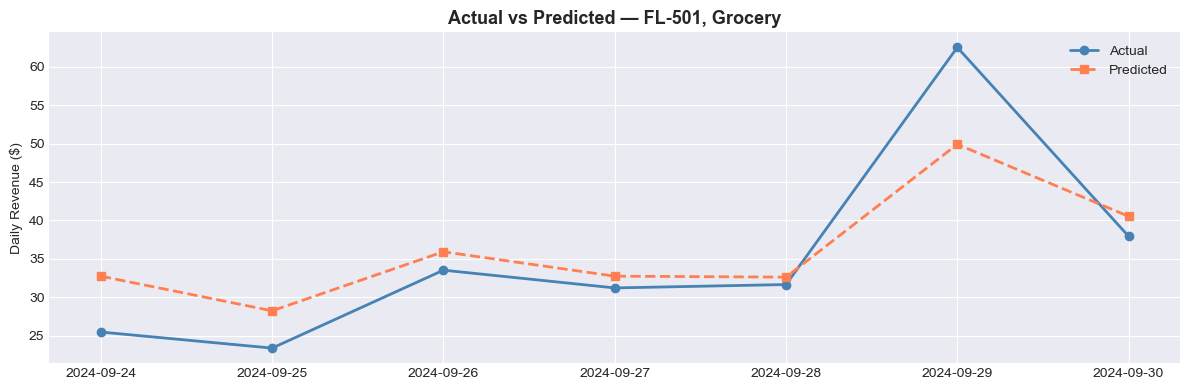

In [23]:
# ── Actual vs Predicted (pick one store + category combo) ─────────────────
test_with_meta = model_df[model_df['date'] > split].copy()
test_with_meta['predicted'] = preds_xgb

sample = test_with_meta[
    (test_with_meta['store_id']  == test_with_meta['store_id'].value_counts().index[0]) &
    (test_with_meta['category'] == 'Grocery')
].sort_values('date')

if len(sample) > 0:
    plt.figure(figsize=(12, 4))
    plt.plot(sample['date'], sample['total_revenue'], label='Actual',    color='steelblue', linewidth=2, marker='o')
    plt.plot(sample['date'], sample['predicted'],     label='Predicted', color='coral',     linewidth=2, linestyle='--', marker='s')
    plt.title(f'Actual vs Predicted — {sample["store_id"].iloc[0]}, Grocery', fontsize=13, fontweight='bold')
    plt.ylabel('Daily Revenue ($)')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No Grocery data for top store in test set — adjust store_id or category filter above.')

In [24]:
print('==='*30)
print(' '*25, 'Model Comparison')
print('==='*30)

comparison = pd.DataFrame({
    'Model': ['Prophet', 'XGBoost'],
    'MAE ($)':  [round(mae_p,2),  round(mae_x,2)],
    'RMSE ($)': [round(rmse_p,2), round(rmse_x,2)],
    'MAPE (%)': [round(mape_p,2), round(mape_x,2)]
})
print('='*45)
print(comparison.to_string(index=False))
print('='*45)
print('\nLower is better for all metrics.')

                          Model Comparison
  Model  MAE ($)  RMSE ($)  MAPE (%)
Prophet  6964.31   7829.19     53.20
XGBoost    16.12     24.60     39.04

Lower is better for all metrics.


In [25]:
print('==='*40)
print(' '*25, 'Business Insights')
print('==='*40)
# ── Top category by revenue ────────────────────────────────────────────────
print('💰 Revenue by Category:')
print(df.groupby('category')['revenue'].sum().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}').to_string())

print('\n📦 Avg Units Sold by Category:')
print(df.groupby('category')['quantity'].mean().sort_values(ascending=False).round(2).to_string())

print('\n📈 Best Performing Regions:')
print(df.groupby('region')['revenue'].sum().sort_values(ascending=False).apply(lambda x: f'${x:,.0f}').to_string())

print('\n🏪 Best Day of Week for Sales:')
dow_map = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
print(df.groupby('dayofweek')['revenue'].sum().rename(dow_map).sort_values(ascending=False).apply(lambda x: f'${x:,.0f}').to_string())

                          Business Insights
💰 Revenue by Category:
category
Emergency        $162,158
Electronics       $92,257
Baby              $91,154
Entertainment     $55,982
Alcohol           $53,125
Household         $34,438
Health            $29,274
Breakfast         $19,389
Snacks            $18,855
Grocery           $17,533

📦 Avg Units Sold by Category:
category
Breakfast        2.51
Emergency        2.38
Alcohol          2.04
Grocery          1.98
Snacks           1.97
Entertainment    1.72
Household        1.51
Health           1.48
Baby             1.47
Electronics      1.25

📈 Best Performing Regions:
region
Central      $171,869
West         $128,078
North         $84,852
Panhandle     $84,153
East          $43,611
South         $42,889

🏪 Best Day of Week for Sales:
dayofweek
Sat    $87,863
Fri    $87,076
Sun    $82,458
Tue    $76,358
Mon    $76,064
Thu    $74,925
Wed    $70,013


In [26]:
print('==='*40)
print(' '*25, 'Saving Models and Encoders')
print('==='*40)
# ── Save XGBoost model ─────────────────────────────────────────────────────
joblib.dump(xgb,      'models/xgboost_walmart.pkl')
joblib.dump(le_cat,   'models/encoder_category.pkl')
joblib.dump(le_store, 'models/encoder_store.pkl')

print(' Saved:')
print('   models/xgboost_walmart.pkl')
print('   models/encoder_category.pkl')
print('   models/encoder_store.pkl')
print('\nTo load and predict:')
print('   model   = joblib.load("models/xgboost_walmart.pkl")')
print('   le_cat  = joblib.load("models/encoder_category.pkl")')
print('   le_st   = joblib.load("models/encoder_store.pkl")')
print('   preds   = model.predict(new_features_df)')

                          Saving Models and Encoders
 Saved:
   models/xgboost_walmart.pkl
   models/encoder_category.pkl
   models/encoder_store.pkl

To load and predict:
   model   = joblib.load("models/xgboost_walmart.pkl")
   le_cat  = joblib.load("models/encoder_category.pkl")
   le_st   = joblib.load("models/encoder_store.pkl")
   preds   = model.predict(new_features_df)


                          Store Performance map


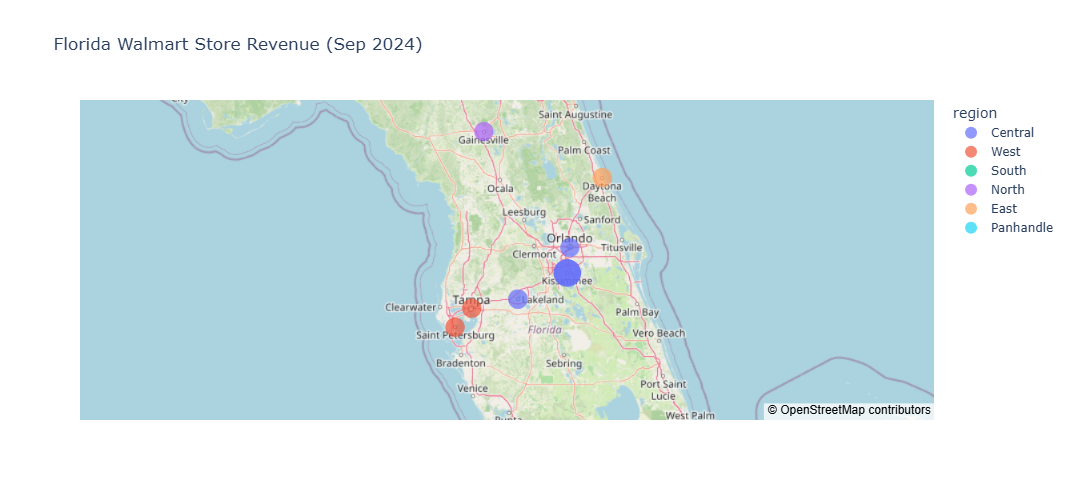

In [27]:
print('==='*40)
print(' '*25, 'Store Performance map')
print('==='*40)
import plotly.express as px

store_rev = df.groupby('store_id')['revenue'].sum().reset_index()
store_map = stores.merge(store_rev, on='store_id', how='left')
store_map['revenue'] = store_map['revenue'].fillna(0)

fig = px.scatter_mapbox(
    store_map,
    lat         = 'latitude',
    lon         = 'longitude',
    size        = 'revenue',
    color       = 'region',
    hover_name  = 'store_name',
    hover_data  = {'revenue': ':$.0f', 'city': True},
    zoom        = 6,
    height      = 500,
    title       = 'Florida Walmart Store Revenue (Sep 2024)',
    mapbox_style= 'open-street-map'
)
fig.show()